STEP 1/6 — Clearing old data & validating source folders
  🗑️  Removed old /kaggle/working/dataset
  ✅ FK folder     : /kaggle/input/datasets/jashandeepsinghmehra/fuzzy-h/FK pic-20210204T031833Z-001
  ✅ Normal folder : /kaggle/input/datasets/jashandeepsinghmehra/fuzzy-h/normal-20210630T193110Z-001

STEP 2/6 — Collecting & validating images
  fungal  : 863 valid  |  0 skipped (corrupt/bad format)
  normal  : 536 valid  |  0 skipped (corrupt/bad format)

  Dataset ready  →  fungal: 863  |  normal: 536

STEP 3/6 — Loading datasets
Found 1399 files belonging to 2 classes.
Using 1120 files for training.
Found 1399 files belonging to 2 classes.
Using 279 files for validation.
  Classes : ['fungal', 'normal']
  Counts  : {'fungal': 863, 'normal': 536}
  Weights : {'fungal': 0.8105, 'normal': 1.305}

STEP 4/6 — Building EfficientNetB3 model
  Total base layers   : 385
  Unfrozen in Phase 2 : 58  (top 15%)

STEP 5/6 — Training  (5 + 5 = 10 total epochs)

  Phase 1 — head warm-up  (5 epochs) …



E0000 00:00:1778434510.444157      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB3_FineTune_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.8457 - auc: 0.9316 - loss: 0.3787 - precision: 0.7746 - recall: 0.9017
Epoch 1: val_loss improved from inf to 0.12156, saving model to /kaggle/working/best_model.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 30s 352ms/step - accuracy: 0.8483 - auc: 0.9331 - loss: 0.3737 - precision: 0.7777 - recall: 0.9032 - val_accuracy: 0.9713 - val_auc: 0.9985 - val_loss: 0.1216 - val_precision: 0.9496 - val_recall: 0.9826 - learning_rate: 0.0010
Epoch 2/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.9806 - auc: 0.9946 - loss: 0.1206 - precision: 0.9547 - recall: 0.9908
Epoch 2: val_loss improved from 0.12156 to 0.10375, saving model to /kaggle/working/best_model.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 208ms/step - accuracy: 0.9807 - auc: 0.9946 - loss: 0.1200 - precision: 0.9551 - recall: 0.9907 - val_accuracy: 0.9821 - val_auc: 0.9995 - val_loss: 0.1038 - val_precision: 0.9661 - val_recall: 0.9913 - learning_rate: 0.0010
Epoch 3/5
35/35 ━━━━━━━━━━━━━

E0000 00:00:1778434576.632813      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB3_FineTune_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.9374 - auc: 0.9854 - loss: 0.2236 - precision: 0.9054 - recall: 0.9215
Epoch 1: val_loss improved from inf to 0.05949, saving model to /kaggle/working/best_model.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 38s 391ms/step - accuracy: 0.9379 - auc: 0.9856 - loss: 0.2221 - precision: 0.9061 - recall: 0.9224 - val_accuracy: 0.9964 - val_auc: 1.0000 - val_loss: 0.0595 - val_precision: 0.9914 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.9875 - auc: 0.9969 - loss: 0.0897 - precision: 0.9778 - recall: 0.9891
Epoch 2: val_loss improved from 0.05949 to 0.05569, saving model to /kaggle/working/best_model.keras
35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 250ms/step - accuracy: 0.9874 - auc: 0.9969 - loss: 0.0898 - precision: 0.9776 - recall: 0.9890 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0557 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/5
35/35 ━━━━━

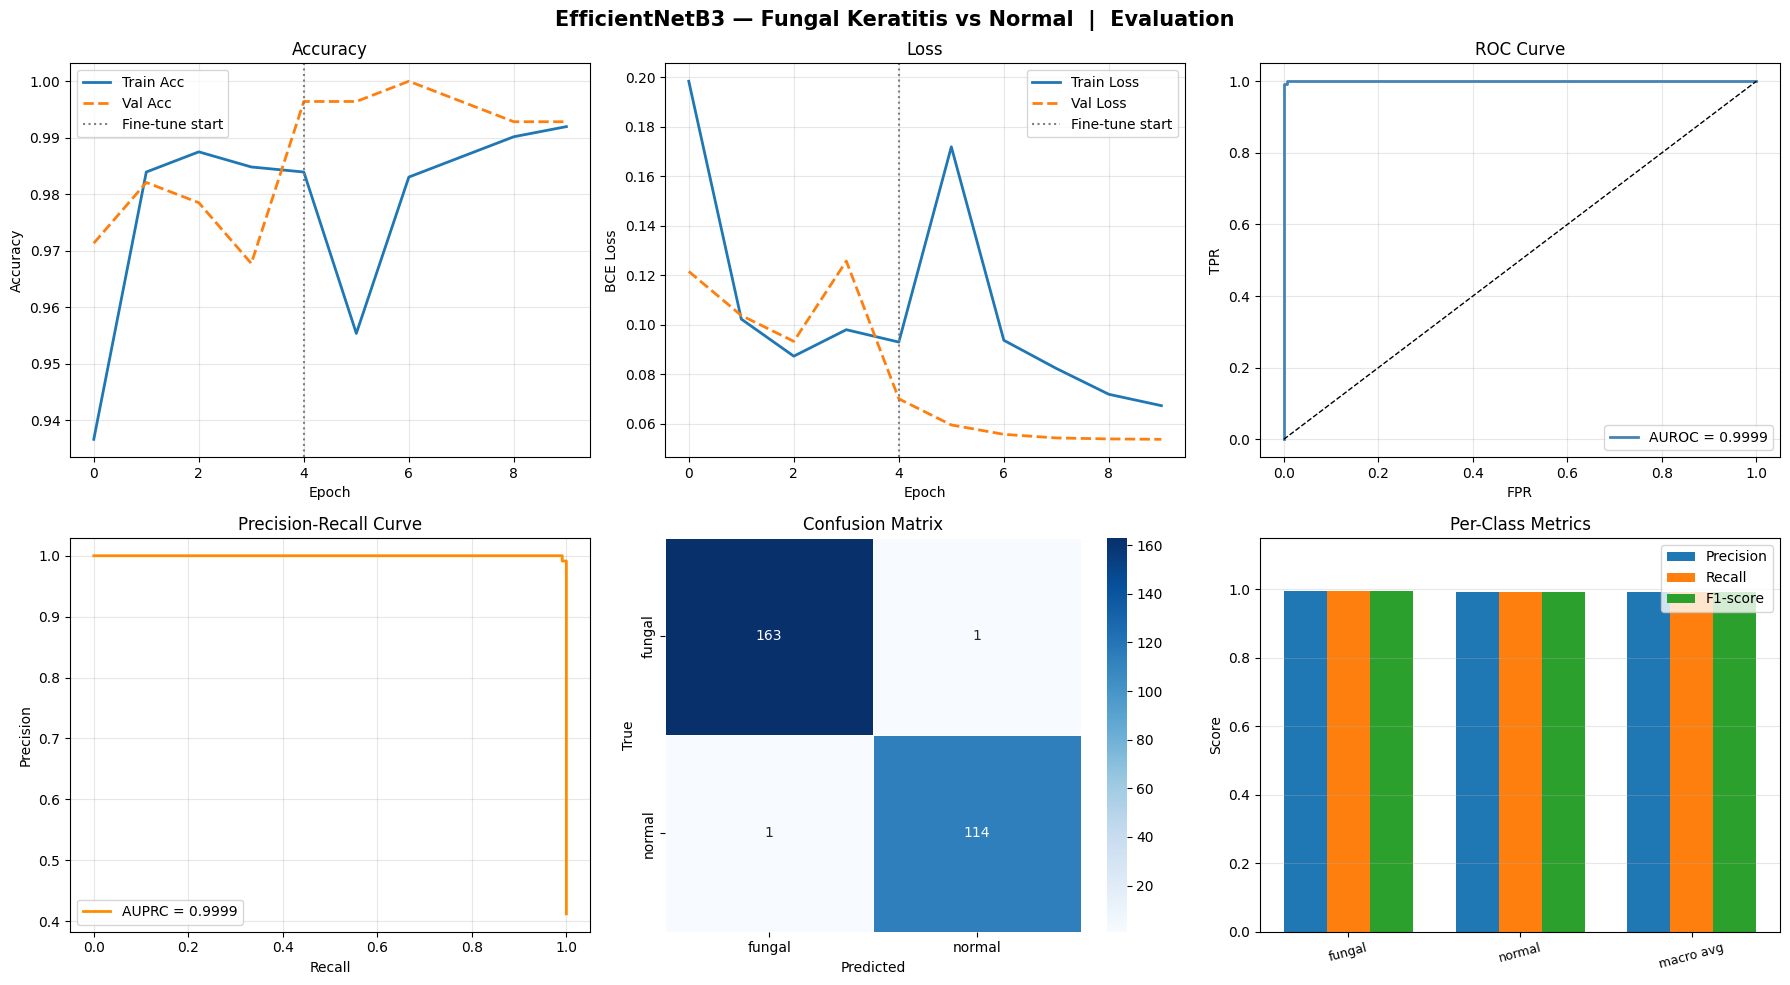


✅  Model  → /kaggle/working/best_model.keras
✅  Plot   → /kaggle/working/evaluation.png
   AUROC : 0.9999   |   AUPRC : 0.9999


In [11]:
# =============================================================================
# EfficientNetB3 — Fungal Keratitis vs Normal  |  Kaggle  |  FINAL
# Fix: force-clears old dataset folder, validates every image with Pillow
# =============================================================================

import os, shutil, warnings
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
)

warnings.filterwarnings("ignore")

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIG  —  correct paths from your previous run output
# ═══════════════════════════════════════════════════════════════════════════════

SRC_FK     = "/kaggle/input/datasets/jashandeepsinghmehra/fuzzy-h/FK pic-20210204T031833Z-001"
SRC_NORMAL = "/kaggle/input/datasets/jashandeepsinghmehra/fuzzy-h/normal-20210630T193110Z-001"

WORK_DIR        = "/kaggle/working"
DATASET_PATH    = os.path.join(WORK_DIR, "dataset")
MODEL_SAVE_PATH = os.path.join(WORK_DIR, "best_model.keras")
PLOT_SAVE_PATH  = os.path.join(WORK_DIR, "evaluation.png")

IMG_SIZE        = (224, 224)
BATCH_SIZE      = 32
EPOCHS_FROZEN   = 5
EPOCHS_FINETUNE = 5
LR_HEAD         = 1e-3
LR_FINETUNE     = 1e-4
VAL_SPLIT       = 0.20
UNFREEZE_TOP    = 0.15
SEED            = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1 — CLEAR OLD DATASET FOLDER  (removes any previously copied bad files)
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("STEP 1/6 — Clearing old data & validating source folders")
print("=" * 65)

if os.path.exists(DATASET_PATH):
    shutil.rmtree(DATASET_PATH)
    print(f"  🗑️  Removed old {DATASET_PATH}")

os.makedirs(os.path.join(DATASET_PATH, "fungal"), exist_ok=True)
os.makedirs(os.path.join(DATASET_PATH, "normal"), exist_ok=True)

assert os.path.isdir(SRC_FK),     f"❌ FK folder not found:\n   {SRC_FK}"
assert os.path.isdir(SRC_NORMAL), f"❌ Normal folder not found:\n   {SRC_NORMAL}"
print(f"  ✅ FK folder     : {SRC_FK}")
print(f"  ✅ Normal folder : {SRC_NORMAL}")


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 2 — COLLECT & VALIDATE  (Pillow opens every file before copying)
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("STEP 2/6 — Collecting & validating images")
print("=" * 65)

# Only extensions TF's decode_image accepts
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}

def is_valid_image(path: str) -> bool:
    try:
        with Image.open(path) as img:
            img.verify()                 # catches corrupt / truncated files
        with Image.open(path) as img:
            img.convert("RGB")           # catches palette / CMYK modes
        return True
    except Exception:
        return False

def collect(src_root: str, class_label: str) -> int:
    dst = os.path.join(DATASET_PATH, class_label)
    ok = bad = 0
    for root, _, files in os.walk(src_root):
        for fname in files:
            if os.path.splitext(fname)[1].lower() not in VALID_EXTS:
                continue
            src_path = os.path.join(root, fname)
            if not is_valid_image(src_path):
                bad += 1
                continue
            # Re-save as clean JPEG so TF always gets a known-good format
            dst_path = os.path.join(dst, f"{class_label}_{ok:05d}.jpg")
            try:
                with Image.open(src_path) as img:
                    img.convert("RGB").save(dst_path, "JPEG", quality=95)
                ok += 1
            except Exception:
                bad += 1
    print(f"  {class_label:8s}: {ok} valid  |  {bad} skipped (corrupt/bad format)")
    return ok

n_fk     = collect(SRC_FK,     "fungal")
n_normal = collect(SRC_NORMAL, "normal")

assert n_fk > 0,     "❌ Zero valid images in FK folder."
assert n_normal > 0, "❌ Zero valid images in Normal folder."
print(f"\n  Dataset ready  →  fungal: {n_fk}  |  normal: {n_normal}")


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 3 — DATA LOADING + CLASS WEIGHTS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("STEP 3/6 — Loading datasets")
print("=" * 65)

ds_kwargs = dict(
    directory        = DATASET_PATH,
    validation_split = VAL_SPLIT,
    seed             = SEED,
    image_size       = IMG_SIZE,
    batch_size       = BATCH_SIZE,
    label_mode       = "binary",
)
train_ds    = tf.keras.utils.image_dataset_from_directory(subset="training",   **ds_kwargs)
val_ds      = tf.keras.utils.image_dataset_from_directory(subset="validation", **ds_kwargs)
CLASS_NAMES = train_ds.class_names
print(f"  Classes : {CLASS_NAMES}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

counts        = [len(os.listdir(os.path.join(DATASET_PATH, c))) for c in CLASS_NAMES]
total_samples = sum(counts)
n_classes     = len(CLASS_NAMES)
class_weights = {i: total_samples / (n_classes * counts[i]) for i in range(n_classes)}
print(f"  Counts  : { {CLASS_NAMES[i]: counts[i]                for i in range(n_classes)} }")
print(f"  Weights : { {CLASS_NAMES[i]: round(class_weights[i],4) for i in range(n_classes)} }")


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 4 — MODEL
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("STEP 4/6 — Building EfficientNetB3 model")
print("=" * 65)

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical", seed=SEED),
    tf.keras.layers.RandomRotation(0.15, seed=SEED),
    tf.keras.layers.RandomZoom(0.15, seed=SEED),
    tf.keras.layers.RandomContrast(0.1, seed=SEED),
    tf.keras.layers.RandomBrightness(0.1, seed=SEED),
], name="augmentation")

inputs     = tf.keras.Input(shape=(*IMG_SIZE, 3), name="input_image")
x          = augmentation(inputs)
base_model = tf.keras.applications.EfficientNetB3(
    include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
base_model.trainable = False

total_layers = len(base_model.layers)
freeze_until = int(total_layers * (1 - UNFREEZE_TOP))
print(f"  Total base layers   : {total_layers}")
print(f"  Unfrozen in Phase 2 : {total_layers - freeze_until}  (top {int(UNFREEZE_TOP*100)}%)")

x       = base_model(x, training=False)
x       = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
x       = tf.keras.layers.BatchNormalization()(x)
x       = tf.keras.layers.Dropout(0.5)(x)
x       = tf.keras.layers.Dense(256, activation="relu",
                                   kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x       = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="prediction")(x)
model   = tf.keras.Model(inputs, outputs, name="EfficientNetB3_FineTune")

def compile_model(mdl, lr):
    mdl.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr),
        loss      = "binary_crossentropy",
        metrics   = ["accuracy",
                     tf.keras.metrics.AUC(name="auc"),
                     tf.keras.metrics.Precision(name="precision"),
                     tf.keras.metrics.Recall(name="recall")],
    )

def make_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5,
            restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(
            MODEL_SAVE_PATH, monitor="val_loss",
            save_best_only=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5,
            patience=3, min_lr=1e-9, verbose=1),
    ]


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 5 — TRAINING
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("STEP 5/6 — Training  (5 + 5 = 10 total epochs)")
print("=" * 65)

# Phase 1 — head only
print(f"\n  Phase 1 — head warm-up  ({EPOCHS_FROZEN} epochs) …\n")
compile_model(model, LR_HEAD)
history1 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_FROZEN, class_weight=class_weights,
    callbacks=make_callbacks(), verbose=1,
)

# Phase 2 — top 20% unfrozen
print(f"\n  Phase 2 — fine-tune top {int(UNFREEZE_TOP*100)}%  ({EPOCHS_FINETUNE} epochs) …\n")
base_model.trainable = True
for layer in base_model.layers[:freeze_until]:
    layer.trainable = False
print(f"  Trainable base layers: "
      f"{sum(1 for l in base_model.layers if l.trainable)} / {total_layers}")

compile_model(model, LR_FINETUNE)
history2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_FINETUNE, class_weight=class_weights,
    callbacks=make_callbacks(), verbose=1,
)

# Merge histories
merged = {k: history1.history[k] + history2.history[k]
          for k in history1.history if k in history2.history}
p1_len = len(history1.history["loss"])


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 6 — EVALUATION & PLOTS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("STEP 6/6 — Evaluation")
print("=" * 65)

y_true, y_prob = [], []
for images, labels in val_ds:
    probs = model(images, training=False).numpy().flatten()
    y_prob.extend(probs)
    y_true.extend(labels.numpy().flatten())

y_true = np.array(y_true)
y_prob = np.array(y_prob)
y_pred = (y_prob >= 0.5).astype(int)

print("\n── Classification Report ──────────────────────────────────")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("EfficientNetB3 — Fungal Keratitis vs Normal  |  Evaluation",
             fontsize=15, fontweight="bold")

def vline(ax):
    ax.axvline(p1_len - 1, color="grey", ls=":", lw=1.5, label="Fine-tune start")

ax = axes[0, 0]
ax.plot(merged["accuracy"],     label="Train Acc", lw=2)
ax.plot(merged["val_accuracy"], label="Val Acc",   lw=2, ls="--")
vline(ax); ax.set_title("Accuracy"); ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(merged["loss"],     label="Train Loss", lw=2)
ax.plot(merged["val_loss"], label="Val Loss",   lw=2, ls="--")
vline(ax); ax.set_title("Loss"); ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 2]
fpr, tpr, _ = roc_curve(y_true, y_prob)
auroc = auc(fpr, tpr)
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"AUROC = {auroc:.4f}")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC Curve"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)

ax = axes[1, 0]
prec_v, rec_v, _ = precision_recall_curve(y_true, y_prob)
auprc = average_precision_score(y_true, y_prob)
ax.plot(rec_v, prec_v, color="darkorange", lw=2, label=f"AUPRC = {auprc:.4f}")
ax.set_title("Precision-Recall Curve"); ax.set_xlabel("Recall")
ax.set_ylabel("Precision"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1, 1]
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=ax)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")

ax = axes[1, 2]
report_dict = classification_report(y_true, y_pred,
                                     target_names=CLASS_NAMES, output_dict=True)
grp      = CLASS_NAMES + ["macro avg"]
met_list = ["precision", "recall", "f1-score"]
data     = np.array([[report_dict[c][m] for m in met_list] for c in grp])
x_pos    = np.arange(len(grp)); w = 0.25
for i, m in enumerate(met_list):
    ax.bar(x_pos + i * w, data[:, i], w, label=m.capitalize())
ax.set_xticks(x_pos + w)
ax.set_xticklabels(grp, rotation=15, fontsize=9)
ax.set_ylim(0, 1.15); ax.set_ylabel("Score")
ax.set_title("Per-Class Metrics"); ax.legend(); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_SAVE_PATH, dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅  Model  → {MODEL_SAVE_PATH}")
print(f"✅  Plot   → {PLOT_SAVE_PATH}")
print(f"   AUROC : {auroc:.4f}   |   AUPRC : {auprc:.4f}")